# GridLock 2.0 EDA Companion

This notebook documents the main data properties and modeling decisions behind the release pipeline.  
It is limited to claims that can be verified directly from the packaged data and artifact files bundled with GridLock 2.0.


## 1. Setup

The notebook is designed to run either from the repository root or directly from the `notebooks/` directory.


In [3]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
def detect_release_root() -> Path:
    current_dir = Path.cwd().resolve()
    candidates = [current_dir, current_dir.parent, current_dir.parent.parent]
    for candidate in candidates:
        if (candidate / "gridlock_release_pipeline.py").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Unable to locate the GridLock 2.0 release root.")
def timestamp_to_minutes(timestamp: str) -> int:
    hour, minute = map(int, str(timestamp).split(':'))
    return hour * 60 + minute
RELEASE_ROOT = detect_release_root()
DATA_DIR = RELEASE_ROOT / 'data'
ARTIFACTS_DIR = RELEASE_ROOT / 'artifacts'
competition_train = pd.read_csv(DATA_DIR / 'competition_train.csv')
competition_test = pd.read_csv(DATA_DIR / 'competition_test.csv')
evaluation_ground_truth = pd.read_csv(DATA_DIR / 'evaluation_ground_truth.csv')
historical = pd.read_csv(DATA_DIR / 'historical_training.csv.xz')
submission = pd.read_csv(ARTIFACTS_DIR / 'submission.csv')
validation_summary = json.loads((ARTIFACTS_DIR / 'validation_summary.json').read_text())
if 'geohash6' in historical.columns:
    historical = historical.rename(columns={'geohash6': 'geohash'})
competition_train['time_min'] = competition_train['timestamp'].map(timestamp_to_minutes)
competition_test['time_min'] = competition_test['timestamp'].map(timestamp_to_minutes)
historical['time_min'] = historical['timestamp'].map(timestamp_to_minutes)
def render_figure(fig):
    if matplotlib.get_backend().lower() != 'agg':
        plt.show()
    else:
        fig.canvas.draw()
    plt.close(fig)


## 2. Packaged datasets

The release package contains four data files:
- official competition train split
- official competition test split
- evaluation ground truth used for local scoring
- historical training data in compressed form

The historical file only contains `geohash`, `day`, `timestamp`, and `demand`. The competition files add the context columns used by the release pipeline.


In [5]:
dataset_summary = pd.DataFrame([
    {"file": "competition_train.csv", "rows": len(competition_train), "columns": ", ".join(competition_train.columns)},
    {"file": "competition_test.csv", "rows": len(competition_test), "columns": ", ".join(competition_test.columns)},
    {"file": "evaluation_ground_truth.csv", "rows": len(evaluation_ground_truth), "columns": ", ".join(evaluation_ground_truth.columns)},
    {"file": "historical_training.csv.xz", "rows": len(historical), "columns": ", ".join(historical.columns)},
])
dataset_summary


,file,rows,columns
0,competition_train.csv,77299,"Index, geohash, day, timestamp, demand, RoadTy..."
1,competition_test.csv,41778,"Index, geohash, day, timestamp, RoadType, Numb..."
2,evaluation_ground_truth.csv,41778,"Index, demand"
3,historical_training.csv.xz,4206321,"geohash, day, timestamp, demand, time_min"


In [6]:
competition_only_columns = sorted(set(competition_train.columns) - set(historical.columns))
competition_only_columns


['Index',
 'Landmarks',
 'LargeVehicles',
 'NumberofLanes',
 'RoadType',
 'Temperature',
 'Weather']

## 3. Day 49 coverage and overlap boundary

A core modeling constraint is the Day 49 gap:
- the official train split contains Day 49 only through `02:00`
- the official test split starts at `02:15` and ends at `13:45`
- the historical file contains the full Day 49 day, so its non-overlap region is `00:00–02:00` plus `14:00–23:45`


In [8]:
train_day49_slots = sorted({timestamp_to_minutes(x) for x in competition_train.loc[competition_train.day == 49, 'timestamp']})
test_day49_slots = sorted({timestamp_to_minutes(x) for x in competition_test['timestamp']})
historical_day49_slots = sorted({timestamp_to_minutes(x) for x in historical.loc[historical.day == 49, 'timestamp']})
historical_non_overlap_slots = [slot for slot in historical_day49_slots if slot not in test_day49_slots]
historical_overlap_slots = [slot for slot in historical_day49_slots if slot in test_day49_slots]

boundary_summary = pd.DataFrame([
    {"set": "competition_train_day49", "slot_count": len(train_day49_slots), "first_slot": train_day49_slots[0], "last_slot": train_day49_slots[-1]},
    {"set": "competition_test_day49", "slot_count": len(test_day49_slots), "first_slot": test_day49_slots[0], "last_slot": test_day49_slots[-1]},
    {"set": "historical_day49_full", "slot_count": len(historical_day49_slots), "first_slot": historical_day49_slots[0], "last_slot": historical_day49_slots[-1]},
    {"set": "historical_day49_non_overlap", "slot_count": len(historical_non_overlap_slots), "first_slot": historical_non_overlap_slots[0], "last_slot": historical_non_overlap_slots[-1]},
])
boundary_summary


,set,slot_count,first_slot,last_slot
0,competition_train_day49,9,0,120
1,competition_test_day49,47,135,825
2,historical_day49_full,96,0,1425
3,historical_day49_non_overlap,49,0,1425


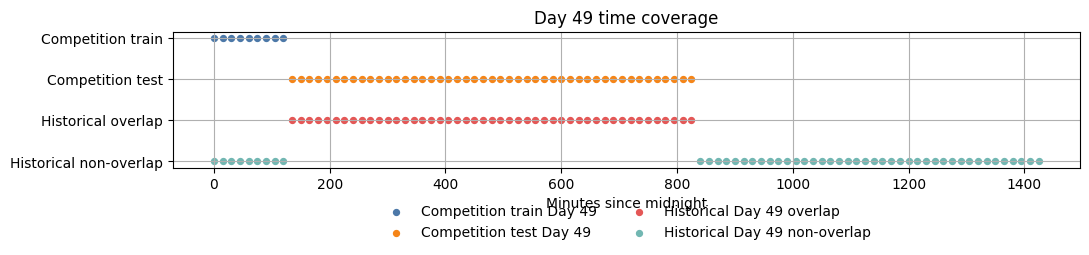

In [9]:
fig, ax = plt.subplots(figsize=(11, 2.8))
for label, slots, color, y in [
    ('Competition train Day 49', train_day49_slots, '#4c78a8', 3),
    ('Competition test Day 49', test_day49_slots, '#f58518', 2),
    ('Historical Day 49 overlap', historical_overlap_slots, '#e45756', 1),
    ('Historical Day 49 non-overlap', historical_non_overlap_slots, '#72b7b2', 0),
]:
    ax.scatter(slots, [y] * len(slots), s=18, label=label, color=color)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(['Historical non-overlap', 'Historical overlap', 'Competition test', 'Competition train'])
ax.set_xlabel('Minutes since midnight')
ax.set_title('Day 49 time coverage')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
plt.tight_layout()
render_figure(fig)


In [10]:
historical_non_overlap_rows = len(historical[(historical.day == 49) & (~historical['time_min'].isin(test_day49_slots))])
historical_non_overlap_rows


27501

## 4. Competition-only metadata columns

The columns `RoadType`, `NumberofLanes`, `LargeVehicles`, `Landmarks`, `Temperature`, and `Weather` do not exist in the historical source file. In the release pipeline they are treated as competition-specific covariates rather than as historical sensor channels.

The notebook does not try to prove the hidden generation mechanism of those columns. It only verifies two observable facts:
1. they are absent from the historical file,
2. they are strongly structured relative to demand and differ in distribution between the official train and test splits.


In [12]:
metadata_missing = pd.DataFrame({
    'competition_train_missing_share': competition_train[['RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']].isna().mean(),
    'competition_test_missing_share': competition_test[['RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']].isna().mean(),
})
metadata_missing


,competition_train_missing_share,competition_test_missing_share
RoadType,0.007762,0.007755
NumberofLanes,0.000000,0.000000
LargeVehicles,0.000000,0.000000
Landmarks,0.000000,0.000000
Temperature,0.032277,0.032290
Weather,0.010311,0.010316


In [13]:
roadtype_share = pd.DataFrame({
    'train': competition_train['RoadType'].fillna('Missing').value_counts(normalize=True),
    'test': competition_test['RoadType'].fillna('Missing').value_counts(normalize=True),
}).fillna(0.0).sort_index()
roadtype_share


,train,test
RoadType,,
Highway,0.046055,0.102255
Missing,0.007762,0.007755
Residential,0.895613,0.808440
Street,0.050570,0.081550


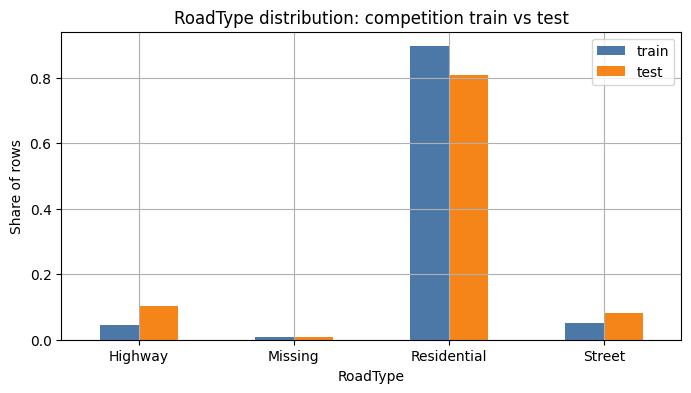

In [14]:
ax = roadtype_share[['train', 'test']].plot(kind='bar', figsize=(8, 4), rot=0, color=['#4c78a8', '#f58518'])
ax.set_ylabel('Share of rows')
ax.set_title('RoadType distribution: competition train vs test')
render_figure(ax.get_figure())


In [15]:
roadtype_demand = competition_train.groupby('RoadType')['demand'].agg(['mean', 'median', 'count']).sort_values('mean')
roadtype_demand


,mean,median,count
RoadType,,,
Residential,0.057209,0.040517,69230
Street,0.273164,0.268124,3909
Highway,0.610756,0.526432,3560


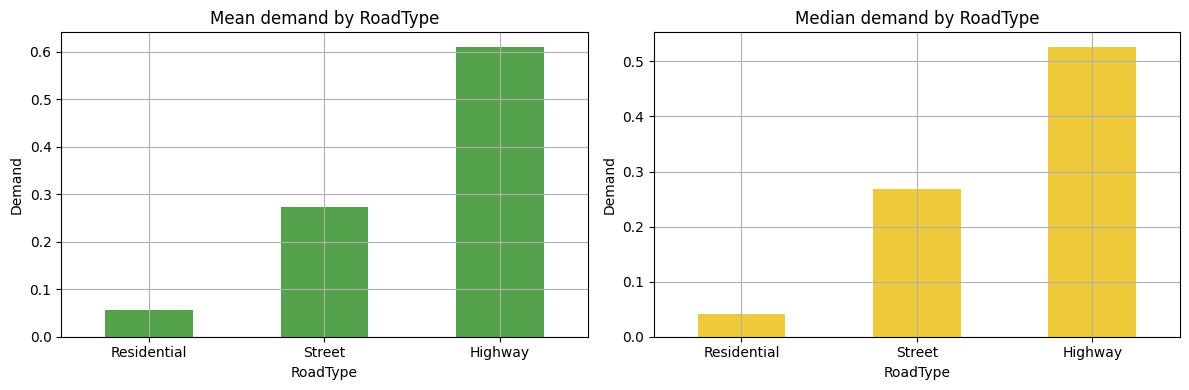

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
roadtype_demand['mean'].plot(kind='bar', ax=axes[0], color='#54a24b', rot=0)
axes[0].set_title('Mean demand by RoadType')
axes[0].set_ylabel('Demand')
roadtype_demand['median'].plot(kind='bar', ax=axes[1], color='#eeca3b', rot=0)
axes[1].set_title('Median demand by RoadType')
axes[1].set_ylabel('Demand')
plt.tight_layout()
render_figure(fig)


## 5. Similar-day analysis
The release model does not assume that every past day is equally informative. It selects basis days by direct correlation against the Day 49 non-overlap proxy.
The table and plot below measure similarity to Day 49 on the official test horizon using the historical file only. The same-weekday candidate `Day 28` appears among the strongest matches, but it is not the single strongest day overall. This matches the observed need for a learned basis set rather than a one-day copy rule.


In [18]:
index = pd.MultiIndex.from_frame(competition_test[['geohash', 'time_min']].drop_duplicates())
d49 = historical[historical.day == 49].set_index(['geohash', 'time_min'])['demand']
rows = []
for day in sorted(historical['day'].unique()):
    if day == 49:
        continue
    candidate = historical[historical.day == day].set_index(['geohash', 'time_min'])['demand']
    target_values = index.map(d49).fillna(0.0).to_numpy(dtype=float)
    candidate_values = index.map(candidate).fillna(0.0).to_numpy(dtype=float)
    if target_values.std() == 0.0 or candidate_values.std() == 0.0:
        continue
    corr = float(np.corrcoef(target_values, candidate_values)[0, 1])
    rows.append({'day': int(day), 'corr_to_day49_test_horizon': corr, 'same_weekday_offset': (49 - int(day)) % 7 == 0})

similarity = pd.DataFrame(rows).sort_values('corr_to_day49_test_horizon', ascending=False).reset_index(drop=True)
similarity.head(15)


,day,corr_to_day49_test_horizon,same_weekday_offset
0,58,0.942792,False
1,59,0.942532,False
2,45,0.940838,False
3,57,0.939297,False
4,60,0.935002,False
5,50,0.934475,False
6,28,0.933421,True
7,3,0.932895,False
8,51,0.929851,False
9,15,0.929690,False


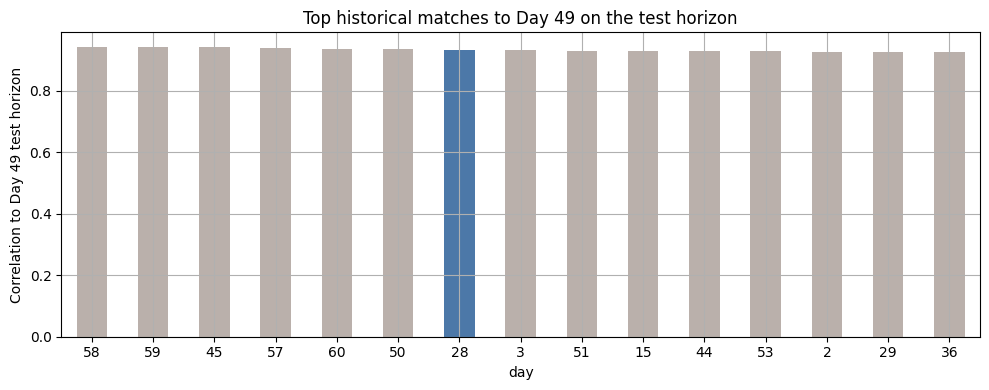

In [19]:
top_similarity = similarity.head(15).copy()
colors = top_similarity['same_weekday_offset'].map({True: '#4c78a8', False: '#bab0ab'})
ax = top_similarity.plot(x='day', y='corr_to_day49_test_horizon', kind='bar', color=colors.tolist(), legend=False, figsize=(10, 4))
ax.set_ylabel('Correlation to Day 49 test horizon')
ax.set_title('Top historical matches to Day 49 on the test horizon')
plt.xticks(rotation=0)
plt.tight_layout()
render_figure(ax.get_figure())


## 6. Feature-engineering breakdown in the release model

The final release pipeline uses the following engineered structures:
- `time_min`: timestamp converted to minutes since midnight
- `geo_4` and `geo_5`: geohash prefixes for hierarchical routing
- historical `(geohash, time_min)` mean baseline
- twelve selected basis-day component channels
- simplex-constrained weights for the global, `geo_4`, and `geo_5` levels
- feature-side boundary control using `RoadType`, `NumberofLanes`, and `LargeVehicles`
- ridge calibration on the observed Day 49 `00:00–02:00` slice
- bounded geohash residual correction derived from the Day 49 non-overlap region


## 7. Packaged run summary and observed score

The release package includes both the scored submission and the historical proxy-fold validation summary. The values below are recomputed directly from the packaged files.


In [22]:
run_log_lines = (ARTIFACTS_DIR / 'run_log.txt').read_text().strip().splitlines()
pd.DataFrame({'run_log': run_log_lines})


,run_log
0,Artifact file : gridlock_release_mo...
1,Submission file : submission.csv
2,"Rows written : 41,778"
3,Missing predictions : 0
4,Basis days : 12
5,Proxy rows : 27501
6,Calibration rows : 7872
7,Residual alpha : 0.30
8,Boundary 1 : 0.187278
9,Boundary 2 : 0.285125


In [23]:
scored_submission = submission.sort_values('Index').reset_index(drop=True)
scored_ground_truth = evaluation_ground_truth.sort_values('Index').reset_index(drop=True)
local_score = float(r2_score(scored_ground_truth['demand'], scored_submission['demand']) * 100.0)

results_summary = pd.DataFrame([
    {'metric': 'Local scored submission R²', 'value': round(local_score, 6)},
    {'metric': 'Proxy-fold mean R²', 'value': round(float(validation_summary['mean_score']), 6)},
    {'metric': 'Proxy-fold median R²', 'value': round(float(validation_summary['median_score']), 6)},
    {'metric': 'Submission rows', 'value': len(scored_submission)},
    {'metric': 'Missing predictions', 'value': int(scored_submission['demand'].isna().sum())},
    {'metric': 'Prediction minimum', 'value': float(scored_submission['demand'].min())},
    {'metric': 'Prediction maximum', 'value': float(scored_submission['demand'].max())},
])
results_summary


,metric,value
0,Local scored submission R²,95.007143
1,Proxy-fold mean R²,91.746914
2,Proxy-fold median R²,94.389219
3,Submission rows,41778.000000
4,Missing predictions,0.000000
5,Prediction minimum,0.000000
6,Prediction maximum,1.000000
